In [91]:
import os
import yaml
import re
import numpy as np
import pandas as pd
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.data import Data
import torch
# dict_values(['1.烯烃C=C伸缩振动', '2.烯烃C-H伸缩振动和变形振动', '3.烯烃的骨架振动'])
def evenly_divide_list(lst, num_groups):
    # 计算每组应该包含的元素数量和余数
    n = len(lst)
    q, r = divmod(n, num_groups)
    group_sizes = [q] * num_groups
    for i in range(r):
        group_sizes[i] += 1

    # 根据每组应该包含的元素数量和余数分配元素
    groups = []
    i = 0
    for size in group_sizes:
        group = lst[i:i+size]
        groups.append(group)
        i += size

    return groups

In [3]:
from Data.base_data import MSAPygDataset
from Data.base_data import Function_group_PygDataset,Spectrum_PygDataset

初始化类

In [3]:
base_dataset = MSAPygDataset()

读取数据

In [8]:
#spectral_data = base_dataset.data_loader('G:\Research\数据集\Pper4-Database\Spectral Database')
Spectrum_loader = Spectrum_PygDataset()
SD = Spectrum_loader.data_loader('G:\Research\数据集\Pper4-Database\Spectral Database')
spectral_data = SD.data

100%|██████████| 306/306 [00:02<00:00, 131.19it/s]


In [7]:
SD.dataset

光谱数据处理

In [9]:
# 生成波长节点
# Strength node.5个区间：1.弱 2.较弱 3.中等 4.较强 5.强
strength_dict = {'5':[0,0.2],'4':[0.2,0.4],'3':[0.4,0.6],'2':[0.6,0.8],'1':[0.8,1]}
for i in spectral_data:
# 将i['Data']的第一列均匀分为20个区间,输出为字典，格式如下：{'区间1':[{行索引1：波长}，{行索引2：波长}]}。行索引1是这个区间的开始，行索引2是这个区间的末端
    #f p > 1:
    #    break
    box = {}
    p = 1
    data = spectral_data[i]['Data']
    a = [i for i in data.iloc[:,0].index]
    b = evenly_divide_list(a, 20)
    # 根据b的索引，在data中选取行
    data_split = [data.loc[i] for i in b]
    for j in data_split:
        Interval = {}
        start = j.iloc[0,0]
        end = j.iloc[-1,0]
        # 判断data_split第二列中的最大值的大小，按照strength_dict的区间划分
        min_value = j.iloc[:,1].min()
        for key in strength_dict:
            if min_value >= 1:
                strength = 1
                break
            if min_value >= strength_dict[key][0] and min_value < strength_dict[key][1]:
                strength = key
                break
        Interval['start'] = start
        Interval['end'] = end
        Interval['strength'] = strength
        box['Node{}'.format(p)] = Interval
        p = p + 1
    all_min = data.iloc[:,1].min()
    # 查找all_min在data中的索引
    Min_index = data[data.iloc[:,1] == all_min].index.tolist()
    Min_index = np.linspace(0,20,len(data))[Min_index[0]]
    # 判断Min_index在哪个区间，举例：如果0<Min_index<1，则位于区间1
    for k in range(20):
        if Min_index > k and Min_index < k+1:
            Min_poistion = f'Node{k+1}'
            break
    box['Min_index'] = [Min_index,Min_poistion]
    spectral_data[i]['Node'] = box
    
   


格式化生成波长节点

In [10]:
spectral_data['26']

{'Path': 'G:\\Research\\数据集\\Pper4-Database\\Spectral Database\\(S=OF)2\\[0]Sulfuryl fluoride, PNNL (x-sec), X=0.01, T=278.14 K, P=1.0 atm, L=15 cm.csv',
 'Name': '[0]Sulfuryl fluoride, PNNL (x-sec), X=0.01, T=278.14 K, P=1.0 atm, L=15 cm.csv',
 'Data':                 nu  \
 0       500.000000   
 1       500.120002   
 2       500.240005   
 3       500.360007   
 4       500.480010   
 ...            ...   
 49995  6499.519990   
 49996  6499.639993   
 49997  6499.759995   
 49998  6499.879998   
 49999  6500.000000   
 
        [0]Sulfurylfluoride-PNNL(x-sec)-X=0.01-T=278.14K-P=1.0atm-L=15cm  
 0                                               1.226004                 
 1                                               1.185981                 
 2                                               1.009619                 
 3                                               1.046930                 
 4                                               1.070633                 
 ...               

In [17]:
# 查找['(CH2=CH)2','C2H4','CH2=CHCI','CH2=CHОCH3','CF2=CF2','C3H6']在这个列表:[value['Path'].split('\\')[-2] for key,value in spectral_data.items()]里面的索引
# 以便找到对应的数据
#ppp = [value['Path'].split('\\')[-2] for key,value in spectral_data.items()]
#zzz = [i for i in range(len(ppp)) if ppp[i] in ['(CH2=CH)2','C2H4','CH2=CHCI','CH2=CHОCH3','CF2=CF2','C3H6']]
#zzz

[9, 34, 37, 79, 146, 150]

In [11]:
spectral_data['147']['Path']

'G:\\Research\\数据集\\Pper4-Database\\Spectral Database\\CH2=CHCI\\[0]Vinyl chloride, HITRAN (x-sec), X=0.01, T=278.1 K, P=1.0 atm, L=15 cm.csv'

In [12]:
test_data = [spectral_data['147']['Node']]
# 创建一个空的dataframe，列名为'Type', 'SubType', 'Functional group', 'Absorb', 'Range', 'Strength'
format_df = pd.DataFrame(columns=['wavelength', 'strength','min_index'])
for i in range(len(test_data)):
    # 将df1的每一行数据输入到format_df中，进行相应的格式化
    for key,value in test_data[i].items():
        if key == 'Min_index':
            format_df.loc[value[1][4:],'min_index'] = 'Feature Node. Minimum transmittance position: {}'.format(value[0])
            'The minimum value of the second column is in the <{}> interval'.format(value)
            #format_df.loc[key,'strength'] = 'The minimum value of the second column is <{}>'.format(spectral_data['26']['Data'].iloc[:,1].min())
            continue
        else:
            format_df.loc[key[4:],'wavelength'] = 'Feature {}. Wavelength: from <{}> to <{}>.(Unit: number of waves)'.format(key,value['start'],value['end'])
            format_df.loc[key[4:],'strength'] = 'Feature {}. Strength: <{}>'.format(key,value['strength'])
            format_df.loc[key[4:],'min_index'] = False

In [29]:
format_df.iloc[0]['wavelength']

'Feature Node1. Wavelength: from <540.0> to <837.886758>.(Unit: number of waves)'

In [109]:
G = nx.Graph()
# 添加节点
# 给G添加节点，节点的名称为'wavelength{}'，{}为自然数列，从1开始，每个节点包含'raw_text'和'color'两个属性".
for i in range(len(format_df)):
    G.add_node(f'wavelength{i+1}',raw_text = format_df.iloc[i]['wavelength'],color = 'green')
    G.add_node(f'strength{i+1}',raw_text = format_df.iloc[i]['strength'],color = 'blue')
    if format_df.iloc[i]['min_index'] != False:
        G.add_node(f'min_index{i+1}',raw_text = format_df.iloc[i]['min_index'],color = 'red')

# 添加边
# 检索所有波长节点，如果相邻的波长节点之间没有边，则添加边
Feature = nx.get_node_attributes(G,'raw_text')
for i in range(len(format_df)):
    if i == len(format_df)-1:
        break
    G.add_edge(f'wavelength{i+1}',f'wavelength{i+2}')

    if eval(re.findall(r'<(.*?)>',Feature[f'strength{i+1}'])[0]) > 1 :
        G.add_edge(f'wavelength{i+1}',f'strength{i+1}')
    # 检测是否G中是否含有对应的min_index节点，如果有，则添加边
    if G.has_node(f'min_index{i+1}'):
        G.add_edge(f'wavelength{i+1}',f'min_index{i+1}')
        if Feature[f'strength{i+1}'] == '1':
                G.add_edge(f'wavelength{i+1}',f'strength{i+1}')
        
# 删除G中没有连线的点
G.remove_nodes_from(list(nx.isolates(G)))


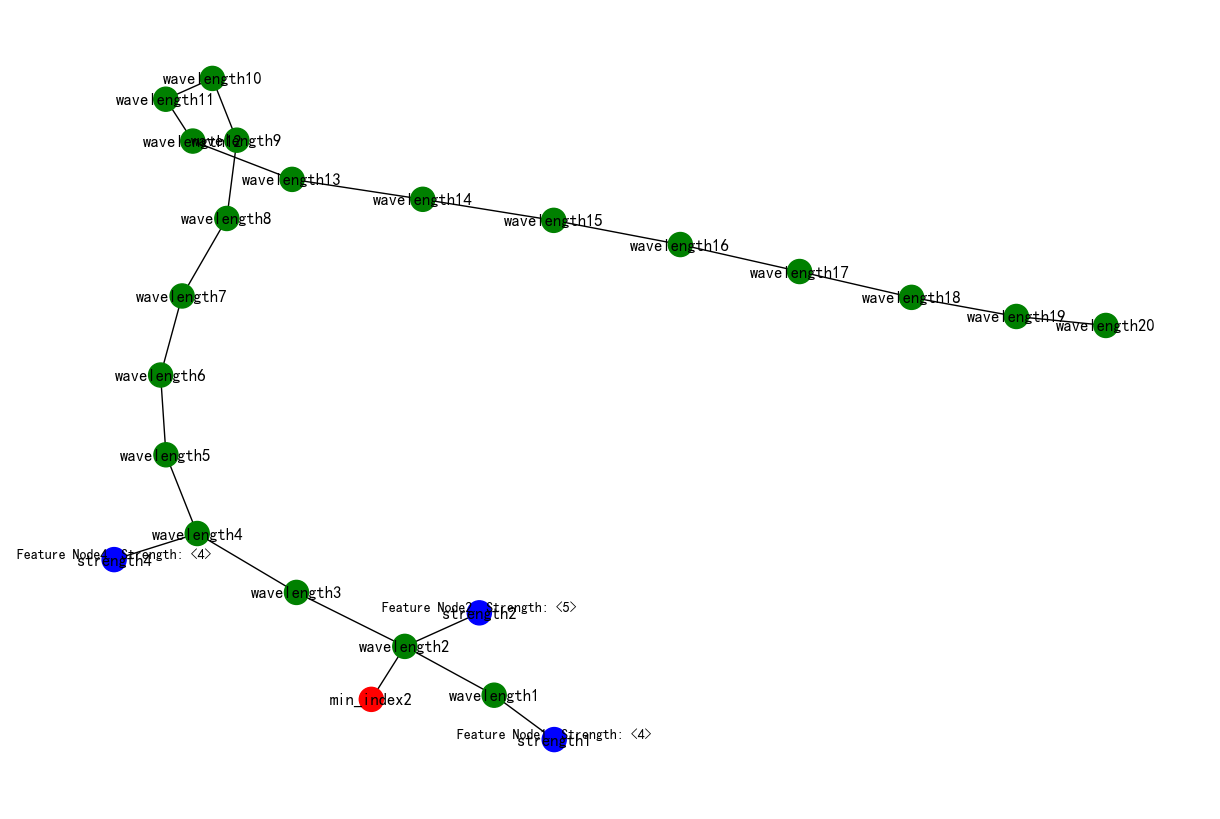

In [146]:
# G图的可视化
def draw_graph(
        graph,
        keys:list = None,#接收列表与字符串
        colors = None,
):
        plt.rcParams['font.sans-serif'] = ['Simhei']  #显示中文
        plt.rcParams['axes.unicode_minus'] = False    #显示负号
        pos = nx.spring_layout(graph)
        colors= [graph.nodes[n]['color'] for n in graph.nodes()] if not colors else colors
        raw_text = nx.get_node_attributes(graph,'raw_text')
        node_labels = {}
        for key,value in raw_text.items():
                # 如果keys中的值存在key中，则将value输入node_labels中，否则不输入
                if isinstance(keys,str):
                        if keys in key:
                                node_labels[key] = value
                elif isinstance(keys,list):
                        for i in keys:
                                if i in key:
                                        node_labels[key] = value

        plt.figure(figsize=(12, 8))
        nx.draw(graph, pos=pos, with_labels=True, 
                node_color=colors
                )


        nx.draw_networkx_labels(graph, pos, labels=node_labels,font_size=10,verticalalignment='bottom')


        edge_labels = nx.get_edge_attributes(graph, 'weight')
        nx.draw_networkx_edge_labels(graph, pos=pos, edge_labels=edge_labels)
        plt.show()

draw_graph(G,keys = 'stren')

In [147]:
# 转为pyg格式
x = torch.ones((G.number_of_nodes(),1), dtype=torch.float)

# 获取图G邻接矩阵的稀疏表示
adj = nx.to_scipy_sparse_array(G).tocoo()

# 获取非零元素行索引
row = torch.from_numpy(adj.row.astype(np.int64)).to(torch.long)
# 获取非零元素列索引
col = torch.from_numpy(adj.col.astype(np.int64)).to(torch.long)

# 将行和列进行拼接，shape变为[2, num_edges], 包含两个列表，第一个是row, 第二个是col
edge_index = torch.stack([row, col], dim=0)

data = Data(x=x, edge_index=edge_index)

node_name = {}
colors = {}
raw_text = {}

cal = 0
for n in G.nodes():
    node_name[cal] = n
    colors[cal] = G.nodes[n]['color']
    raw_text[cal] = G.nodes[n]['raw_text']
    cal = cal + 1

data.node_name = node_name
data.colors= colors
data.raw_text = raw_text


In [148]:
len([i+1 for i in range(data.x.shape[0])])

24

In [150]:
to_networkx = nx.Graph()
# 使用 add_nodes_from 批处理的效率比 add_node 高
to_networkx.add_nodes_from([i for i in range(data.x.shape[0])])
# 使用 add_edges_from 批处理的效率比 add_edge 高
edges = np.array(data.edge_index.T, dtype=int)
to_networkx.add_edges_from(edges)
## 根据data中的color属性，给图中的节点添加这个属性
nx.set_node_attributes(to_networkx, data.colors, 'color')
## 根据data中的raw_text属性，给图中的节点添加这个属性
nx.set_node_attributes(to_networkx, data.raw_text, 'raw_text')
## 根据data中的node_name属性，将节点重新命名
to_networkx = nx.relabel_nodes(to_networkx, data.node_name)

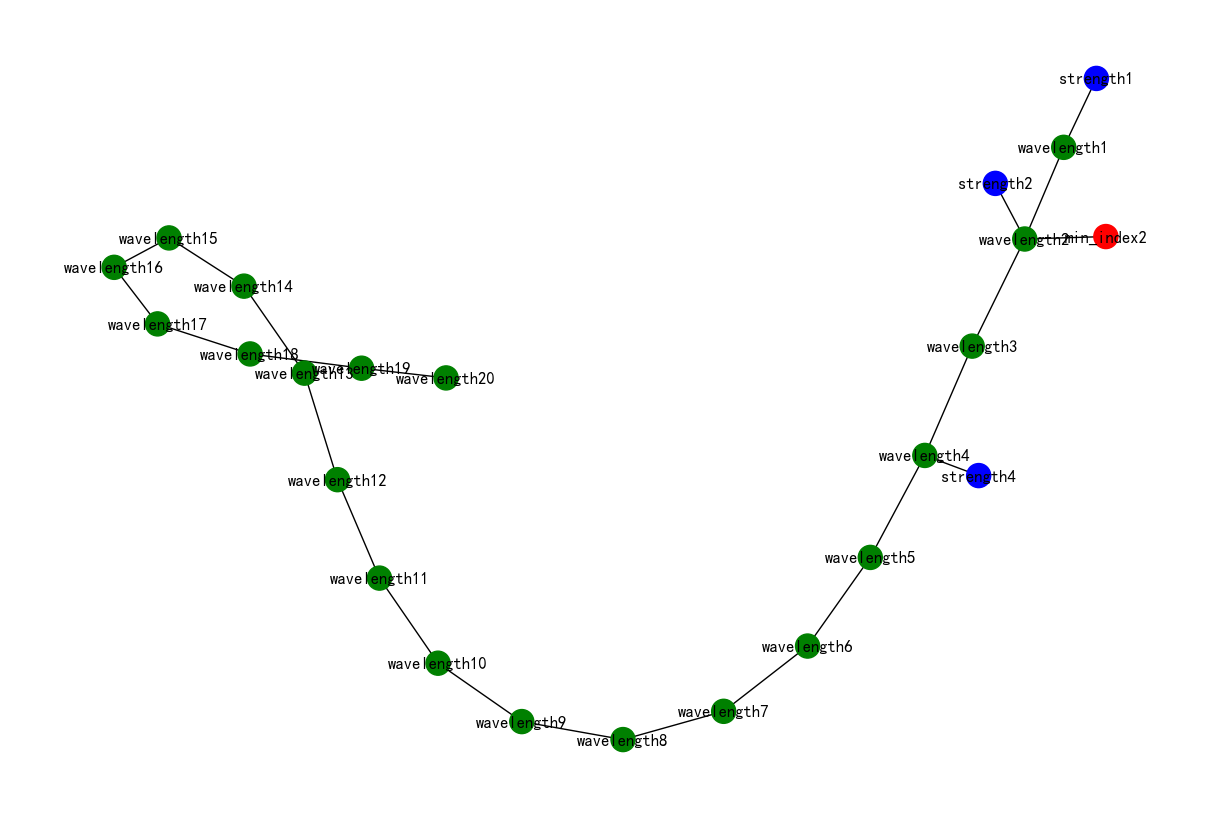

In [151]:
draw_graph(to_networkx)

In [152]:
for i in to_networkx.nodes(data=True):
    print(i)


('wavelength1', {'color': 'green', 'raw_text': 'Feature Node1. Wavelength: from <540.0> to <837.886758>.(Unit: number of waves)'})
('strength1', {'color': 'blue', 'raw_text': 'Feature Node1. Strength: <4>'})
('wavelength2', {'color': 'green', 'raw_text': 'Feature Node2. Wavelength: from <838.00596> to <1135.892718>.(Unit: number of waves)'})
('strength2', {'color': 'blue', 'raw_text': 'Feature Node2. Strength: <5>'})
('min_index2', {'color': 'red', 'raw_text': 'Feature Node. Minimum transmittance position: 1.3496269925398507'})
('wavelength3', {'color': 'green', 'raw_text': 'Feature Node3. Wavelength: from <1136.01192> to <1433.898678>.(Unit: number of waves)'})
('wavelength4', {'color': 'green', 'raw_text': 'Feature Node4. Wavelength: from <1434.01788> to <1731.904638>.(Unit: number of waves)'})
('strength4', {'color': 'blue', 'raw_text': 'Feature Node4. Strength: <4>'})
('wavelength5', {'color': 'green', 'raw_text': 'Feature Node5. Wavelength: from <1732.02384> to <2029.910598>.(Unit

In [36]:
nx.get_node_attributes(G, 'raw_text')

{'wavelength1': 'Feature Node1. Wavelength: from <540.0> to <837.886758>.(Unit: number of waves)',
 'strength1': 'Feature Node1. Strength: <4>',
 'wavelength2': 'Feature Node2. Wavelength: from <838.00596> to <1135.892718>.(Unit: number of waves)',
 'strength2': 'Feature Node2. Strength: <5>',
 'min_index2': 'Feature Node. Minimum transmittance position: 1.3496269925398507',
 'wavelength3': 'Feature Node3. Wavelength: from <1136.01192> to <1433.898678>.(Unit: number of waves)',
 'strength3': 'Feature Node3. Strength: <1>',
 'wavelength4': 'Feature Node4. Wavelength: from <1434.01788> to <1731.904638>.(Unit: number of waves)',
 'strength4': 'Feature Node4. Strength: <4>',
 'wavelength5': 'Feature Node5. Wavelength: from <1732.02384> to <2029.910598>.(Unit: number of waves)',
 'strength5': 'Feature Node5. Strength: <1>',
 'wavelength6': 'Feature Node6. Wavelength: from <2030.029801> to <2327.916558>.(Unit: number of waves)',
 'strength6': 'Feature Node6. Strength: <1>',
 'wavelength7': '

In [53]:
G = nx.Graph()
# 添加节点
for i in 
G.add_nodes_from(format_df['wavelength']
                 #, color='r'
                 )
G.add_nodes_from(format_df['strength']
                 #, color='b'
                 )
G.add_nodes_from(format_df['min_index']
                 #, color='g'
                 )

# 以设定的中心为轴，添加连线
# 规模：Type->SubType->Functional group->Absorb->Range->Strength

for i in range(len(format_df)):
    # 先连波长
    wavlength1 = format_df.iloc[i]['wavelength']
    if i+1 < len(format_df):
        wavlength2 = format_df.iloc[i+1]['wavelength']
        if G.has_edge(wavlength1, wavlength2):
            pass
        else:G.add_edge(wavlength1, wavlength2)

    # 再连强度
    strength = format_df.iloc[i]['strength']
    if G.has_edge(wavlength1, strength):
        pass
    elif int(re.search("<(.+?)>", strength).group(1)) > 1: # 太弱的就不加特征节点 这里回头可以改一下可靠,为什么findall不行?
        G.add_edge(wavlength1, strength)

    # 最后查看是否应该与最小值相连接
    Min_index = format_df.iloc[i]['min_index']
    if Min_index:
        if G.has_edge(wavlength1, Min_index):
            pass
        else:
            G.add_edge(wavlength1, Min_index)
            # 检测此时的强度是否为1，如果为1的话，也连接W-S
            if format_df.iloc[i]['strength'] == '1':
                G.add_edge(wavlength1, strength)

    # 删除所有没有连线的节点
    without_edge = []
    for node in G.nodes:
        if len(G.edges(node)) == 0:
            without_edge.append(node)
    G.remove_nodes_from(without_edge)

    # 为图中的3类节点分别添加颜色属性,或者说分类标识
    for node in G.nodes:
        if 'Wavelength' in node:
            G.nodes[node]['color'] = 'g'
        elif 'Strength' in node:
            G.nodes[node]['color'] = 'b'
        elif 'Minimum transmittance position' in node:
            G.nodes[node]['color'] = 'r'

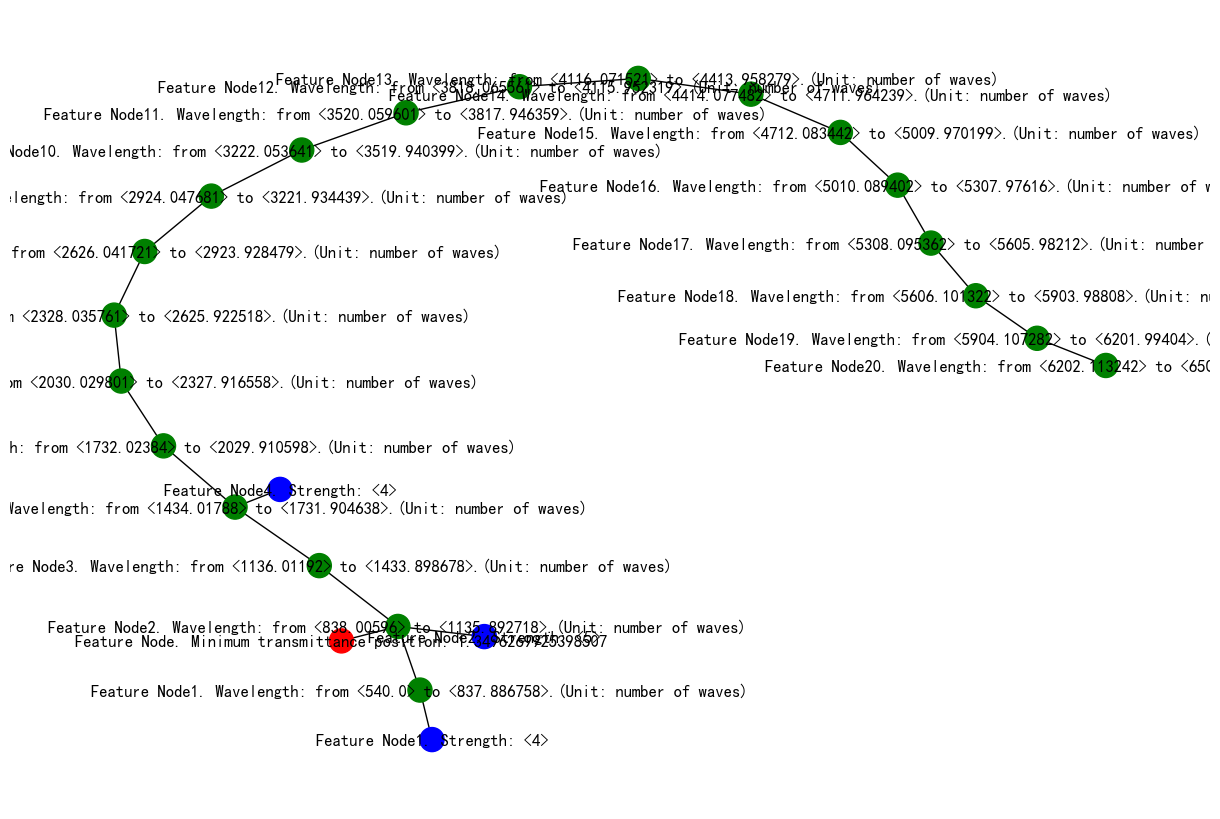

In [54]:
# 图像可视化
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Simhei']  #显示中文
plt.rcParams['axes.unicode_minus'] = False    #显示负号
pos = nx.spring_layout(G)
colors= [G.nodes[n]['color'] for n in G.nodes()]

plt.figure(figsize=(12, 8))
nx.draw(G, pos=pos, with_labels=True, 
        node_color=colors
        )
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels)
plt.show()

选取几个特定的样本进行测试

In [15]:
format_df.iloc[3]['min_index']

'Feature Node. Minimum transmittance position: 3.3476669533390666'

In [6]:
spectral_data['26']['Node']

{'Node1': {'start': 500.0, 'end': 799.885998, 'strength': '5'},
 'Node2': {'start': 800.006, 'end': 1099.891998, 'strength': '5'},
 'Node3': {'start': 1100.012, 'end': 1399.897998, 'strength': '5'},
 'Node4': {'start': 1400.018, 'end': 1699.903998, 'strength': '5'},
 'Node5': {'start': 1700.024, 'end': 1999.909998, 'strength': '1'},
 'Node6': {'start': 2000.030001, 'end': 2299.915998, 'strength': '1'},
 'Node7': {'start': 2300.036001, 'end': 2599.921998, 'strength': '1'},
 'Node8': {'start': 2600.042001, 'end': 2899.927999, 'strength': '1'},
 'Node9': {'start': 2900.048001, 'end': 3199.933999, 'strength': '1'},
 'Node10': {'start': 3200.054001, 'end': 3499.939999, 'strength': '1'},
 'Node11': {'start': 3500.060001, 'end': 3799.945999, 'strength': '1'},
 'Node12': {'start': 3800.066001, 'end': 4099.951999, 'strength': '1'},
 'Node13': {'start': 4100.072001, 'end': 4399.957999, 'strength': '1'},
 'Node14': {'start': 4400.078002, 'end': 4699.963999, 'strength': '1'},
 'Node15': {'start': 

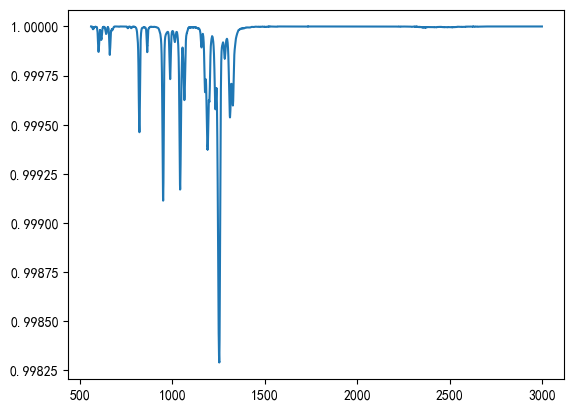

In [56]:
plt.plot(spectral_data['1']['Data'].iloc[:,0],spectral_data['1']['Data'].iloc[:,1])


光谱预处理

In [4]:
# 光谱的数据进行节点化处理
# ata = self.get_ofa_data(dataset_config)   # 获取数据，并进行LLM处理，这一步之后，相关数据已经嵌入类属性中
# split = self.get_data_split(dataset_config)  # 分割数据集，train-vaild-test
# stage_name = self.get_stage_name(stage_config, dataset_config)

NameError: name 'self' is not defined

加载官能团信息

In [8]:
# 从excel文件中读取数据
FG_data = base_dataset.load_function_group()

1.烯烃C=C伸缩振动


g:\Research\Paper4-Code\2024_5_13\Data\base_data.py:124: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1.烯烃C=C伸缩振动' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  value.loc[:,'备注'] = key


2.烯烃C-H伸缩振动和变形振动


g:\Research\Paper4-Code\2024_5_13\Data\base_data.py:124: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '2.烯烃C-H伸缩振动和变形振动' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  value.loc[:,'备注'] = key


3.烯烃的骨架振动


g:\Research\Paper4-Code\2024_5_13\Data\base_data.py:124: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '3.烯烃的骨架振动' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  value.loc[:,'备注'] = key


In [9]:
FG_data['3.烯烃的骨架振动']
#dict_values(['1.烯烃C=C伸缩振动', '2.烯烃C-H伸缩振动和变形振动', '3.烯烃的骨架振动'])

,文本名称,Latex,Smiles,范围,强度,备注
0,None,R-CH=CH_{2},None,635;550;485-445,s;s;m-s,3.烯烃的骨架振动
1,顺式烯烃,None,None,670-455,s,3.烯烃的骨架振动
2,反式烯烃,None,None,455-370,m-s,3.烯烃的骨架振动
3,无支链顺式,R-CH=CH_{2},None,490-465,s,3.烯烃的骨架振动
4,无支链反式,R-CH=CH_{2},None,325-285,s,3.烯烃的骨架振动
5,顺式,RCH=CHR_{2},None,630-575;500-475,s;s,3.烯烃的骨架振动
6,反式,RCH=CHR_{2},None,580-515;500-480;455-370,m-s;m-s;m-s,3.烯烃的骨架振动
7,None,C(-[3]{R^{1}})(-[5]{R^{2}})=CH2,[1[R1]]C([2[R2]])=C,560-530;470-435,s;m,3.烯烃的骨架振动
8,None,C(-[3]{R^{1}})(-[5]{R^{2}})=CHR^{3},[R1]C=C([1[R2]])[2*],570-515,s,3.烯烃的骨架振动
9,芳基烯烃,None,None,525-470;450-395;550,s;m-s;m,3.烯烃的骨架振动


处理为节点的形式

In [10]:
# 构建图谱
graph_function_group = base_dataset.construct_graph_from_text(FG_data)

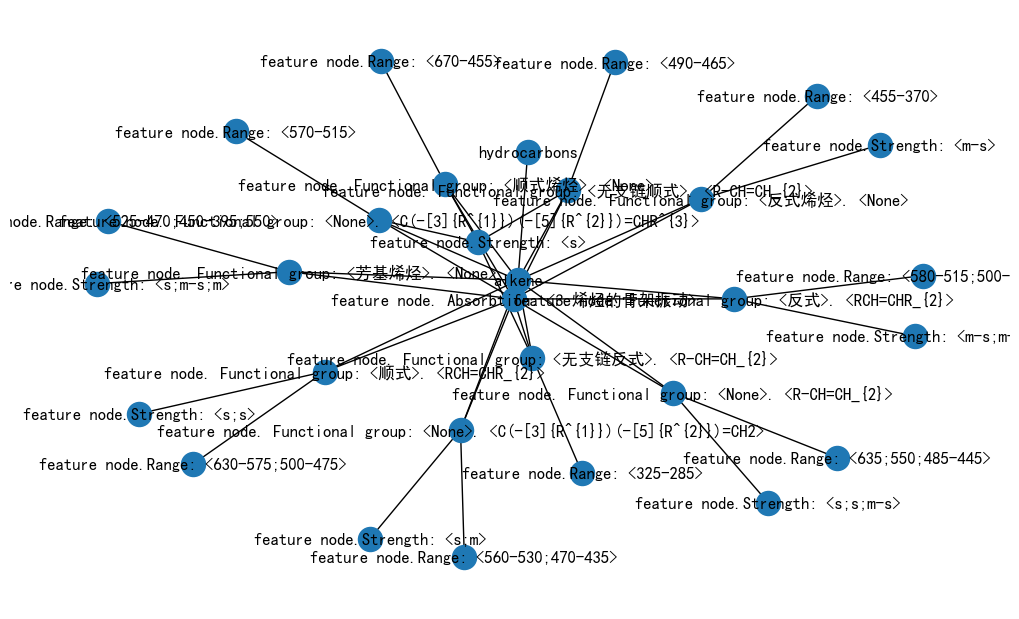

In [11]:
#图谱可视化
base_dataset.graph_visualisation(graph_function_group)

混合处理

In [197]:
graph_function_group.nodes

NodeView(('hydrocarbons', 'alkene', 'feature node. Functional group: <None>. <R-CH=CH_{2}>', 'feature node. Functional group: <顺式烯烃>. <None>', 'feature node. Functional group: <反式烯烃>. <None>', 'feature node. Functional group: <无支链顺式>. <R-CH=CH_{2}>', 'feature node. Functional group: <无支链反式>. <R-CH=CH_{2}>', 'feature node. Functional group: <顺式>. <RCH=CHR_{2}>', 'feature node. Functional group: <反式>. <RCH=CHR_{2}>', 'feature node. Functional group: <None>. <C(-[3]{R^{1}})(-[5]{R^{2}})=CH2>', 'feature node. Functional group: <None>. <C(-[3]{R^{1}})(-[5]{R^{2}})=CHR^{3}>', 'feature node. Functional group: <芳基烯烃>. <None>', 'feature node. Absorbtion: <3.烯烃的骨架振动>', 'feature node.Range: <635;550;485-445>', 'feature node.Range: <670-455>', 'feature node.Range: <455-370>', 'feature node.Range: <490-465>', 'feature node.Range: <325-285>', 'feature node.Range: <630-575;500-475>', 'feature node.Range: <580-515;500-480;455-370>', 'feature node.Range: <560-530;470-435>', 'feature node.Range: <570-51

In [188]:
# 1.查询graph_function_group中所有官能团的Range节点
range_node = []
for node in graph_function_group.nodes:
    if 'Range' in node:
        print(node)
        range_node.append(node)
# 2.选取光谱图像G中的Strength节点
print('--------------------------------')
for node in G.nodes:
    if 'Strength' in node:
        print(node)
# 3.查询光谱图像G中与Strength节点相连的Wavelength节点
print('--------------------------------')
wave = []
for node in G.nodes:
    if 'Strength' in node:
        print(node)
        print([n for n in G.neighbors(node)])
        wave.append([n for n in G.neighbors(node)])
print('--------------------------------')
       

feature node.Range: <635;550;485-445>
feature node.Range: <670-455>
feature node.Range: <455-370>
feature node.Range: <490-465>
feature node.Range: <325-285>
feature node.Range: <630-575;500-475>
feature node.Range: <580-515;500-480;455-370>
feature node.Range: <560-530;470-435>
feature node.Range: <570-515>
feature node.Range: <525-470;450-395;550>
--------------------------------
Feature Node1. Strength: <4>
Feature Node2. Strength: <5>
Feature Node4. Strength: <4>
--------------------------------
Feature Node1. Strength: <4>
['Feature Node1. Wavelength: from <540.0> to <837.886758>.(Unit: number of waves)']
Feature Node2. Strength: <5>
['Feature Node2. Wavelength: from <838.00596> to <1135.892718>.(Unit: number of waves)']
Feature Node4. Strength: <4>
['Feature Node4. Wavelength: from <1434.01788> to <1731.904638>.(Unit: number of waves)']
--------------------------------


In [189]:
# 查找光谱图像G中的波长节点可能对应的官能团种类,输出的格式为{波长节点:[官能团节点,]}
connected_dict = {}
for i in wave:  # 遍历对应了强度的波长节点
    start_wave =  eval(re.findall(r'<(.*?)>', i[0])[0])
    end_wave = eval(re.findall(r'<(.*?)>', i[0])[1])
    print('--------------------------------')
    print(i[0])
    connected_node = []
    for j in range_node: # 遍历官能团信息
        #print('--')
        # 根据分号进行划分
        Peak = re.findall(r'<(.*?)>', j)[0].split(';')
        #print(Peak)
        for k in Peak:
            #print(k)
            # 这里有两种情况,一种是单独的点,另一种是范围
            if '-' in k: # 这是范围的
                end = eval(k.split('-')[0])
                start = eval(k.split('-')[1])
                discrete_point = np.linspace(start, end, 100)
                # 统计discrete_point中有多少个点落在start_wave和end_wave之间,输出这些点的总数
                discrete_number = 0
                for p in discrete_point:
                    if p >= start_wave and p <= end_wave:
                        discrete_number += 1
                #print('占比数为{}'.format(discrete_number/100))
                if discrete_number/100 > 0.5:
                    #print(f'{i[0]} is in the {k} range')
                    print('{}-{} is in the {}'.format(k,j,i))
                    connected_node.append(j)

                #if start >= start_wave and end <= end_wave:
                #    print(f'{i[0]} is in the {k} range')
            else: # 这是单独的点
                #print(k)
                if eval(k) >= start_wave and eval(k) <= end_wave:
                    #print(f'{i[0]} is in the {k} range')
                    print('{}-{} is in the {}'.format(k,j,i))
                    connected_node.append(j)
                    continue
    connected_dict[i[0]] = connected_node

for key,value in connected_dict.items():
    # 删除value中的重复元素
    value = list(set(value))
    connected_dict[key] = value
    

--------------------------------
Feature Node1. Wavelength: from <540.0> to <837.886758>.(Unit: number of waves)
635-feature node.Range: <635;550;485-445> is in the ['Feature Node1. Wavelength: from <540.0> to <837.886758>.(Unit: number of waves)']
550-feature node.Range: <635;550;485-445> is in the ['Feature Node1. Wavelength: from <540.0> to <837.886758>.(Unit: number of waves)']
670-455-feature node.Range: <670-455> is in the ['Feature Node1. Wavelength: from <540.0> to <837.886758>.(Unit: number of waves)']
630-575-feature node.Range: <630-575;500-475> is in the ['Feature Node1. Wavelength: from <540.0> to <837.886758>.(Unit: number of waves)']
580-515-feature node.Range: <580-515;500-480;455-370> is in the ['Feature Node1. Wavelength: from <540.0> to <837.886758>.(Unit: number of waves)']
560-530-feature node.Range: <560-530;470-435> is in the ['Feature Node1. Wavelength: from <540.0> to <837.886758>.(Unit: number of waves)']
570-515-feature node.Range: <570-515> is in the ['Featu

In [93]:
connected_dict

{'Feature Node1. Wavelength: from <540.0> to <837.886758>.(Unit: number of waves)': ['feature node.Range: <580-515;500-480;455-370>',
  'feature node.Range: <560-530;470-435>',
  'feature node.Range: <630-575;500-475>',
  'feature node.Range: <670-455>',
  'feature node.Range: <570-515>',
  'feature node.Range: <525-470;450-395;550>',
  'feature node.Range: <635;550;485-445>'],
 'Feature Node2. Wavelength: from <838.00596> to <1135.892718>.(Unit: number of waves)': [],
 'Feature Node4. Wavelength: from <1434.01788> to <1731.904638>.(Unit: number of waves)': []}

In [190]:
# 根据搜索的结果重新绘图
# 0.复制原图
G_copy = G.copy()
# 1.查询
target_function_group = {}
for key,value in connected_dict.items():
    # 查询与波长节点相连的官能团分子节点
    TFG = []
    for i in value:
        TFG.append([n for n in graph_function_group.neighbors(i)][0])
    target_function_group[key] = TFG
# 2.添加
for key,value in target_function_group.items():
    for i in value:
        new_graph = nx.generators.ego_graph(graph_function_group, i, radius=1)
        # 将new_graph中的节点添加到G_copy中
        # 检测new_graph中的节点是否存在于G_copy中,如果不存在的话,添加该节点
        for node in new_graph.nodes:
            if G_copy.has_node(node):
                pass
            else:
                G_copy.add_node(node)
        # 检测new_graph中的边是否存在于G_copy中,如果不存在的话,添加该条边线
        for edge in new_graph.edges:
            if G_copy.has_edge(edge[0],edge[1]):
                pass
            else:
                G_copy.add_edge(edge[0],edge[1])
    
        # 3.连线
        # 检测key和i是否相连,如果不相连,则添加连线
        if G_copy.has_edge(key,i):
            pass
        else:
            G_copy.add_edge(key,i)


In [187]:
target_function_group

{'Feature Node1. Wavelength: from <540.0> to <837.886758>.(Unit: number of waves)': ['feature node. Functional group: <反式>. <RCH=CHR_{2}>',
  'feature node. Functional group: <None>. <C(-[3]{R^{1}})(-[5]{R^{2}})=CH2>',
  'feature node. Functional group: <顺式>. <RCH=CHR_{2}>',
  'feature node. Functional group: <顺式烯烃>. <None>',
  'feature node. Functional group: <None>. <C(-[3]{R^{1}})(-[5]{R^{2}})=CHR^{3}>',
  'feature node. Functional group: <芳基烯烃>. <None>',
  'feature node. Functional group: <None>. <R-CH=CH_{2}>'],
 'Feature Node2. Wavelength: from <838.00596> to <1135.892718>.(Unit: number of waves)': [],
 'Feature Node4. Wavelength: from <1434.01788> to <1731.904638>.(Unit: number of waves)': []}

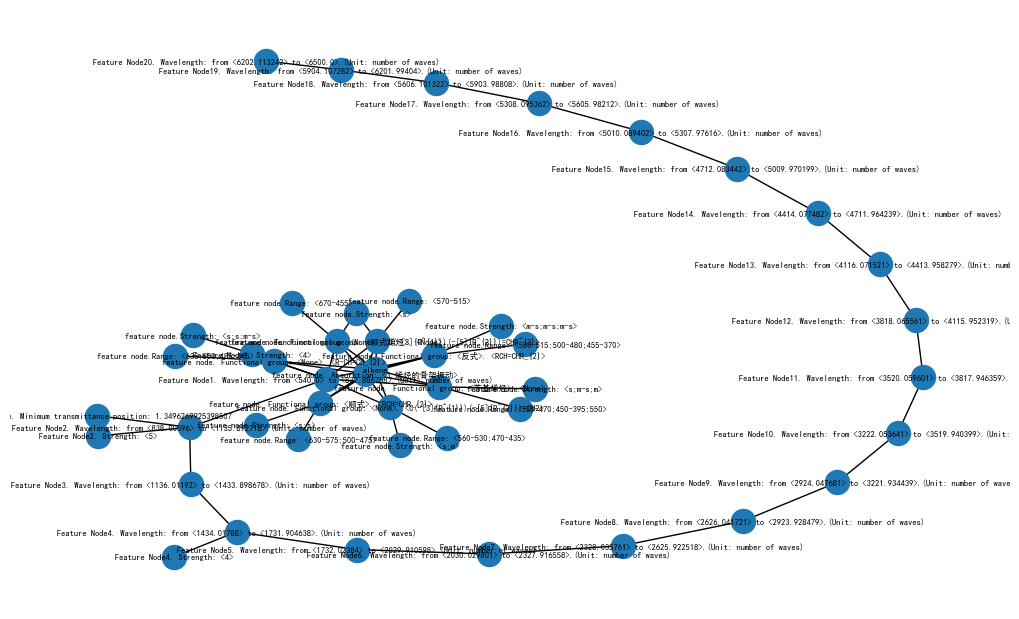

In [192]:
# 图像可视化
ppp = G_copy
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Simhei']  #显示中文
plt.rcParams['axes.unicode_minus'] = False    #显示负号
pos = nx.spring_layout(ppp)
#colors= [G.nodes[n]['color'] for n in G.nodes()]

plt.figure(figsize=(10, 6))
nx.draw(ppp, pos=pos, with_labels=True,font_size=6)
edge_labels = nx.get_edge_attributes(ppp, 'weight')
nx.draw_networkx_edge_labels(ppp, pos=pos, edge_labels=edge_labels)
plt.show()

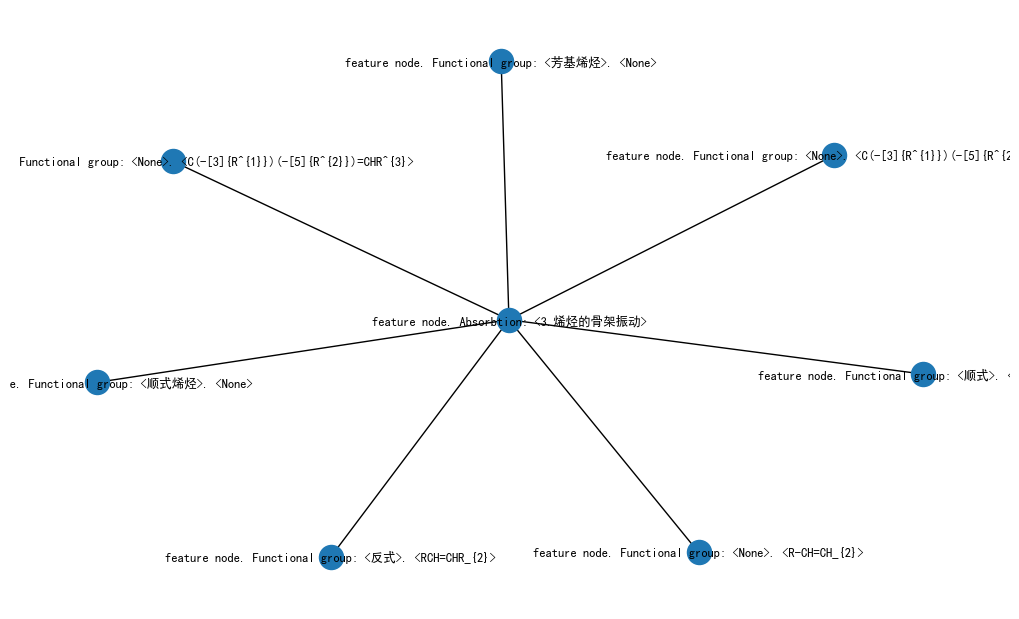

In [195]:
# 检查图的细节
new_graph = nx.generators.ego_graph(G_copy, 'feature node. Absorbtion: <3.烯烃的骨架振动>', radius=1)
#new_graph = nx.generators.ego_graph(G_copy, 'Feature Node1. Wavelength: from <540.0> to <837.886758>.(Unit: number of waves)', radius=1)
#new_graph = nx.generators.ego_graph(G_copy, 'alkene', radius=1)
ppp = new_graph

plt.rcParams['font.sans-serif'] = ['Simhei']  #显示中文
plt.rcParams['axes.unicode_minus'] = False    #显示负号
pos = nx.spring_layout(ppp)
#colors= [G.nodes[n]['color'] for n in G.nodes()]

plt.figure(figsize=(10, 6))
nx.draw(ppp, pos=pos, with_labels=True,font_size=9)
edge_labels = nx.get_edge_attributes(ppp, 'weight')
nx.draw_networkx_edge_labels(ppp, pos=pos, edge_labels=edge_labels)
plt.show()

In [169]:
# 从不同的图格式之间进行转换
#pyg_format = base_dataset.GP.from_networkx_2_pyg(graph_function_group)
#pyg_format
#nwx_format = base_dataset.GP.from_pyg_2_networkx(pyg_format)
#nwx_format

In [31]:
# 转换后的可视化结果
#base_dataset.graph_visualisation()
#base_dataset.graph_visualisation(graph_function_group)
#base_dataset.graph_visualisation(nwx_format)

#### 测试内容

In [ ]:
# 节点的格式说明

# 1.Type; 2.SubType; 3.Functional group; 4.Absorb; 5.Range; 6.Srength

# 1.Type节点，子节点，包括烃类，含氮化合物，含氧化合物，含硫化合物，含卤化合物，有机硼化合物，有机磷化合物，有机硅化合物。之后的LLM处理的格式如下：
# 1.feature node. Type:<information>  

# 2.SubType节点，子节点，指的是化合物进一步分类。之后的LLM处理的格式如下：
# 2.feature node. SubType:<information>

# 3.Functional group节点，中心节点，其它全部都是分支。之后的LLM处理的格式如下：
# 3.feature node. Functional group: <information>. <Molecular>

# 4.Absorb节点，子节点，指的是吸收。之后的LLM处理的格式如下：
# 4.feature node. Absorbtion:<information>

# 5.Range节点，子节点，指的是范围。之后的LLM处理的格式如下：
# 5.feature node.Range:<information>

# 6.Strength节点，子节点，指的是强度。之后的LLM处理的格式如下：
# 6.feature node.Strength:<information>

In [34]:
# 把df1处理成标准格式
df1 = FG_data['1.烯烃C=C伸缩振动']
# 创建一个空的dataframe，列名为'Type', 'SubType', 'Functional group', 'Absorb', 'Range', 'Strength'
format_df = pd.DataFrame(columns=['Type', 'SubType', 'Functional group', 'Absorb', 'Range', 'Strength'])
for i in range(len(df1)):
    # 将df1的每一行数据输入到format_df中，进行相应的格式化
    format_df.loc[i,'Type'] = 'hydrocarbons' # 烃类
    format_df.loc[i,'SubType'] = 'alkene' # 烯烃
    format_df.loc[i,'Functional group'] = 'feature node. Functional group: <{}>. <{}>'.format(df1.loc[i,'文本名称'],df1.loc[i,'Latex'])
    format_df.loc[i,'Absorb'] = 'feature node. Absorbtion: <{}>'.format(df1.loc[i,'备注'])
    format_df.loc[i,'Range'] = 'feature node.Range: <{}>'.format(df1.loc[i,'范围'])
    format_df.loc[i,'Strength'] = 'feature node.Strength: <{}>'.format(df1.loc[i,'强度'])
    


In [35]:
format_df

,Type,SubType,Functional group,Absorb,Range,Strength
0,hydrocarbons,alkene,feature node. Functional group: <孤立>. <C=C>,feature node. Absorbtion: <1.烯烃C=C伸缩振动>,feature node.Range: <1680-1620>,feature node.Strength: <w-m>
1,hydrocarbons,alkene,feature node. Functional group: <与芳香基共轭>. <C=C>,feature node. Absorbtion: <1.烯烃C=C伸缩振动>,feature node.Range: <1640-1610>,feature node.Strength: <m>
2,hydrocarbons,alkene,feature node. Functional group: <与C=C或C=O共轭>. ...,feature node. Absorbtion: <1.烯烃C=C伸缩振动>,feature node.Range: <1660-1580>,feature node.Strength: <s>
3,hydrocarbons,alkene,feature node. Functional group: <共轭>. <CH_{2}=...,feature node. Absorbtion: <1.烯烃C=C伸缩振动>,feature node.Range: <1620-1610>,feature node.Strength: <s>
4,hydrocarbons,alkene,feature node. Functional group: <乙烯基端基>. <-CH=...,feature node. Absorbtion: <1.烯烃C=C伸缩振动>,feature node.Range: <1645-1640>,feature node.Strength: <w-m>
5,hydrocarbons,alkene,"feature node. Functional group: <乙烯基端基,X=Cl,Br...",feature node. Absorbtion: <1.烯烃C=C伸缩振动>,feature node.Range: <1620-1595>,feature node.Strength: <s>
6,hydrocarbons,alkene,"feature node. Functional group: <乙烯基端基,乙烯基醚>. ...",feature node. Absorbtion: <1.烯烃C=C伸缩振动>,feature node.Range: <1640-1630;1620-1610>,feature node.Strength: <s;s>
7,hydrocarbons,alkene,"feature node. Functional group: <乙烯基端基,乙烯基酮>. ...",feature node. Absorbtion: <1.烯烃C=C伸缩振动>,feature node.Range: <1620-1615>,feature node.Strength: <s>
8,hydrocarbons,alkene,"feature node. Functional group: <乙烯基端基,乙烯酸脂>. ...",feature node. Absorbtion: <1.烯烃C=C伸缩振动>,feature node.Range: <1700-1645>,feature node.Strength: <s>
9,hydrocarbons,alkene,"feature node. Functional group: <乙烯基端基,丙烯酸酯>. ...",feature node. Absorbtion: <1.烯烃C=C伸缩振动>,feature node.Range: <1640-1635;1625-1620>,feature node.Strength: <s>


In [36]:
test_dataframe = format_df.iloc[:3]
test_dataframe

,Type,SubType,Functional group,Absorb,Range,Strength
0,hydrocarbons,alkene,feature node. Functional group: <孤立>. <C=C>,feature node. Absorbtion: <1.烯烃C=C伸缩振动>,feature node.Range: <1680-1620>,feature node.Strength: <w-m>
1,hydrocarbons,alkene,feature node. Functional group: <与芳香基共轭>. <C=C>,feature node. Absorbtion: <1.烯烃C=C伸缩振动>,feature node.Range: <1640-1610>,feature node.Strength: <m>
2,hydrocarbons,alkene,feature node. Functional group: <与C=C或C=O共轭>. ...,feature node. Absorbtion: <1.烯烃C=C伸缩振动>,feature node.Range: <1660-1580>,feature node.Strength: <s>


In [37]:
# 创建大图
G = nx.Graph()
# 添加节点
G.add_nodes_from(test_dataframe['Type'], color='r')
G.add_nodes_from(test_dataframe['SubType'], color='b')
G.add_nodes_from(test_dataframe['Functional group'], color='g')
G.add_nodes_from(test_dataframe['Absorb'], color='y')
G.add_nodes_from(test_dataframe['Range'], color='c')
G.add_nodes_from(test_dataframe['Strength'], color='m')

In [38]:
# 以设定的中心为轴，添加连线
# 规模：Type->SubType->Functional group->Absorb->Range->Strength

for i in range(len(test_dataframe)):
    Type = test_dataframe.iloc[i]['Type']
    SubType = test_dataframe.iloc[i]['SubType']
    Functional_group = test_dataframe.iloc[i]['Functional group']
    Absorb = test_dataframe.iloc[i]['Absorb']
    Range = test_dataframe.iloc[i]['Range']
    Strength = test_dataframe.iloc[i]['Strength']
    if G.has_edge(Type, SubType): # 大类连线
        pass
    else:G.add_edge(Type, SubType)
    if G.has_edge(SubType, Functional_group): # 小类连线
        pass
    else:G.add_edge(SubType, Functional_group)
    if G.has_edge(Functional_group, test_dataframe.iloc[i]['Absorb']): # 功能组连线
        pass
    else:G.add_edge(Functional_group, Absorb)
    if G.has_edge(Functional_group, Range): # 吸收连线
        pass
    else:G.add_edge(Functional_group, Range)
    if G.has_edge(Functional_group, Strength): # 范围连线
        pass
    else:G.add_edge(Functional_group, Strength)
    #if not pd.isna(score):
    #    if G.has_edge(student, subject):
    #        G[student][subject]['weight'] += score # 这里是设置了权重
    #    else:
    #        G.add_edge(student, subject, weight=score)

In [40]:
# 从networkx转换为pytorch_geometric
from torch_geometric.data import Data
# 将G保存为统一的pyg格式
# 创建节点特征矩阵
x = torch.ones((G.number_of_nodes(),1), dtype=torch.float)

# 获取图G邻接矩阵的稀疏表示
adj = nx.to_scipy_sparse_array(G).tocoo()

# 获取非零元素行索引
row = torch.from_numpy(adj.row.astype(np.int64)).to(torch.long)
# 获取非零元素列索引
col = torch.from_numpy(adj.col.astype(np.int64)).to(torch.long)

# 将行和列进行拼接，shape变为[2, num_edges], 包含两个列表，第一个是row, 第二个是col
edge_index = torch.stack([row, col], dim=0)

data = Data(x=x, edge_index=edge_index)
data.raw_text = list(G.nodes)
# 根据data.raw_text创建字典，以自然数为键
data.raw_text_dict = {i:data.raw_text[i] for i in range(len(data.raw_text))}

In [41]:
data.raw_text_dict

{0: 'hydrocarbons',
 1: 'alkene',
 2: 'feature node. Functional group: <孤立>. <C=C>',
 3: 'feature node. Functional group: <与芳香基共轭>. <C=C>',
 4: 'feature node. Functional group: <与C=C或C=O共轭>. <C=C>',
 5: 'feature node. Absorbtion: <1.烯烃C=C伸缩振动>',
 6: 'feature node.Range: <1680-1620>',
 7: 'feature node.Range: <1640-1610>',
 8: 'feature node.Range: <1660-1580>',
 9: 'feature node.Strength: <w-m>',
 10: 'feature node.Strength: <m>',
 11: 'feature node.Strength: <s>'}

In [42]:
# 测试能否从pytorch_geometric转换为networkx
# 方法1
#from torch_geometric.utils.convert import to_networkx
#G1 = to_networkx(data,node_attrs=data.raw_text)

# 方法2
G2 = nx.Graph()
# 使用 add_nodes_from 批处理的效率比 add_node 高
G2.add_nodes_from(data.raw_text)
# 使用 add_edges_from 批处理的效率比 add_edge 高
edges = np.array(data.edge_index.T, dtype=int)
# 根据data.raw_text_dict，将edges中的数字替换为字符串
edges = [[data.raw_text_dict[i] for i in edge] for edge in edges]
G2.add_edges_from(edges)

#G1.nodes = data.raw_text

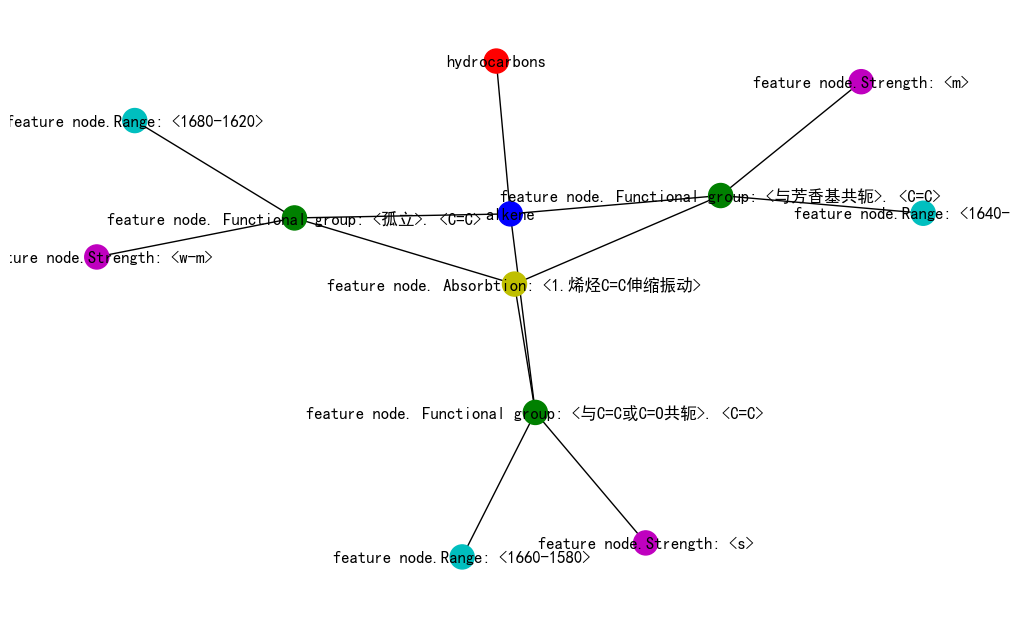

In [45]:
# 图像可视化
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Simhei']  #显示中文
plt.rcParams['axes.unicode_minus'] = False    #显示负号
pos = nx.spring_layout(G)
colors= [G.nodes[n]['color'] for n in G.nodes()]

plt.figure(figsize=(10, 6))
nx.draw(G, pos=pos, with_labels=True, node_color=colors)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels)
plt.show()

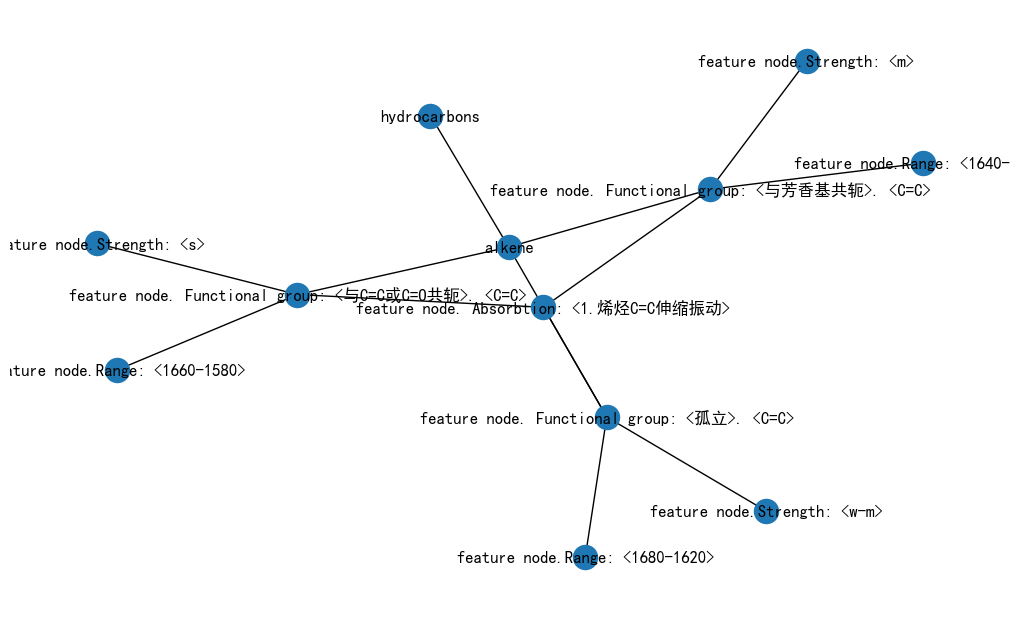

In [50]:
# 图像可视化
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Simhei']  #显示中文
plt.rcParams['axes.unicode_minus'] = False    #显示负号
pos = nx.spring_layout(G2)
# 修改pos的key值for i in data.raw_text]
#data.raw_text[i] = data.raw_text.pop(i)
#pos = {zzz[key]: value for key, value in pos.items()}
#colors= [G.nodes[n]['color'] for n in G1.nodes()]

plt.figure(figsize=(10, 6))
nx.draw(G2, pos=pos, 
        with_labels=True
        )
edge_labels = nx.get_edge_attributes(G2, 'weight')
nx.draw_networkx_edge_labels(G2, pos=pos, edge_labels=edge_labels)
plt.show()

In [12]:
# 应该保存为如下所示的pt格式
cur_path = r'G:\Research\Graph_torch_test\data\single_graph\Cora'
path = os.path.join(cur_path, "cora.pt")
data = torch.load(path)

In [15]:
type(data)

torch_geometric.data.data.Data

文本信息预处理

In [ ]:

        
        
        # Evaluation datasets are constructed only once.包括验证和测试的数据集只构建一次
        if stage_config["stage"] != "train" and stage_name in self.stage_names[stage_config["stage"]]:
            return self.stage_names[stage_config["stage"]].index(stage_name) # 返回这个eval数据集的索引
        global_data = self.get_global_data(dataset_config)  # 进行预处理，例如构建图等 
        prompt_feats = data.get_prompt_text_feat(dataset_config["task_level"]) # Prompt的相关部分
        data = globals()[dataset_config["construct"]](dataset=data, split=split, split_name=stage_config["split_name"],
                                                      prompt_feats=prompt_feats, to_bin_cls_func=globals()[
                dataset_config["process_label_func"]] if dataset_config.get("process_label_func") else None,
                                                      task_level=dataset_config["task_level"], global_data=global_data,
                                                      **dataset_config["args"], )
        # 类别为subgraph的数据集，例如SubgraphHierDataset。用来从大的图中提取子图
        if stage_config["stage"] == "train":
            self.datasets[stage_config["stage"]].append(data)
        else:
            eval_data = make_data(stage_config["dataset"], data, stage_config["split_name"],
                                  dataset_config["eval_metric"], globals()[dataset_config["eval_func"]],
                                  dataset_config["num_classes"], batch_size=self.eval_batch_size,
                                  sample_size=self.sample_size, eval_mode=dataset_config["eval_mode"])
            self.datasets[stage_config["stage"]].append(eval_data)
        self.stage_names[stage_config["stage"]].append(stage_name)
        return self.stage_names[stage_config["stage"]].index(stage_name)   #